## Mt. SAC Spring 2026 CISD 43 Final Project FIFA Player Analysis
## Completed by Juan Nevares
---



Repository Link:

https://github.com/jn-sbccd-student/Mt_SAC_CISD_43_Spring_2026_Final_Project_FIFA_Players_by_Juan_Nevares

**Team:**
* Juan Nevares

**Course:** CISD 43 – BIG DATA (Spring, 2026)

### Problem Statement
* The project aims to perform data analysis, machine learning, and data to database importing through using a dataset containing FIFA Players and the various information, reputations, positions, physical stats, etc. of each respective player. With this amount of information, we can be able to make more accurate analysis or inferences between the various players. A later prediction was applied using Linear Regression machine learning techniques on both Google Colab and RapidMiner to determine a trend in weight (kgs) relative to the FIFA Player's ability stats. The data was also later imported onto a MongoDB Database for later storage of, in a future case, potential big data projects and retrieval.
    
    
    
* **Keywords:** FIFA, FIFA Players, Pandas, Google Colab, Linear Regression, Machine Learning, MongoDB, NoSQL, Data, Database, Stats, Data Visualization


### Required packages

* The list of packages is noted below:


In [ ]:
# Import necessary libraries
# CISD 43 (Spring 2026) at Mt. SAC
# Final Project
# Assignment worked on by Juan Nevares in Google Colab
# 6/7/2026

# Note that print PDF may cut off due to an issue with rendering on Colab:
# https://github.com/googlecolab/colabtools/issues/4357
# https://github.com/googlecolab/colabtools/issues/5505

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mpl_toolkits
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

### Set up and install MongoDB and relevant Python Libraries for use within Google Colab's environment

In [ ]:
!lsb_release -a

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy


In [ ]:
!sudo apt-get install gnupg curl

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (7.81.0-1ubuntu1.24).
gnupg is already the newest version (2.2.27-3ubuntu2.5).
0 upgraded, 0 newly installed, 0 to remove and 8 not upgraded.


In [ ]:
!curl -fsSL https://pgp.mongodb.com/server-8.0.asc | \
    sudo gpg -o /usr/share/keyrings/mongodb-server-8.0.gpg \
    --dearmor

gpg: cannot open '/dev/tty': No such device or address
curl: (23) Failed writing body


In [ ]:
!echo "deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-8.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/8.0 multiverse" | sudo tee /etc/apt/sources.list.d/mongodb-org-8.0.list

deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-8.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/8.0 multiverse


In [ ]:
!sudo apt-get update

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/8.0 InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!sudo apt-get install -y mongodb-org

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
mongodb-org is already the newest version (8.0.23).
0 upgraded, 0 newly installed, 0 to remove and 8 not upgraded.


In [ ]:
!mkdir -p /data/db
!sudo chown -R mongodb:mongodb /data/db

In [ ]:
!mongod --dbpath /data/db --bind_ip 127.0.0.1 --logpath /data/db/mongod.log --fork

about to fork child process, waiting until server is ready for connections.
forked process: 137376
ERROR: child process failed, exited with 1
To see additional information in this output, start without the "--fork" option.


In [ ]:
!tail /data/db/mongod.log

{"t":{"$date":"2026-06-08T05:31:58.596+00:00"},"s":"I",  "c":"SHARDING", "id":4784921, "ctx":"initandlisten","msg":"Shutting down the MigrationUtilExecutor"}
{"t":{"$date":"2026-06-08T05:31:58.596+00:00"},"s":"I",  "c":"ASIO",     "id":22582,   "ctx":"MigrationUtil-TaskExecutor","msg":"Killing all outstanding egress activity."}
{"t":{"$date":"2026-06-08T05:31:58.596+00:00"},"s":"I",  "c":"CONTROL",  "id":4784928, "ctx":"initandlisten","msg":"Shutting down the TTL monitor"}
{"t":{"$date":"2026-06-08T05:31:58.596+00:00"},"s":"I",  "c":"CONTROL",  "id":6278511, "ctx":"initandlisten","msg":"Shutting down the Change Stream Expired Pre-images Remover"}
{"t":{"$date":"2026-06-08T05:31:58.596+00:00"},"s":"I",  "c":"CONTROL",  "id":4784929, "ctx":"initandlisten","msg":"Acquiring the global lock for shutdown"}
{"t":{"$date":"2026-06-08T05:31:58.596+00:00"},"s":"I",  "c":"-",        "id":4784931, "ctx":"initandlisten","msg":"Dropping the scope cache for shutdown"}
{"t":{"$date":"2026-06-08T05:31:

In [ ]:
!pip install pymongo

In [ ]:
from pymongo import MongoClient
from pprint import pprint

In [ ]:
# See full rows text (Non-Truncated)
# https://pandas.pydata.org/docs/reference/api/pandas.set_option.html#pandas.set_option

pd.set_option("display.max_columns", None)

### Read the dataset and examine any potential issues to later address during cleansing

In [ ]:
df = pd.read_csv("data/fifa_players.csv")
df

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,wage_euro,preferred_foot,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),body_type,release_clause_euro,national_team,national_rating,national_team_position,national_jersey_number,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,565000.0,Left,5,4,4,Messi,226500000.0,Argentina,82.0,RF,10.0,86,95,70,92,86,97,93,94,89,96,91,86,93,95,95,85,68,72,66,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,205000.0,Right,3,5,4,Lean,133800000.0,Denmark,78.0,CAM,10.0,88,81,52,91,80,84,86,87,89,91,76,73,80,88,81,84,50,92,58,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,255000.0,Right,4,4,5,Normal,144200000.0,France,84.0,RDM,6.0,80,75,75,86,85,87,85,82,90,90,71,79,76,82,66,90,83,88,87,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,165000.0,Right,3,4,4,Normal,105400000.0,Italy,83.0,LW,10.0,86,77,56,85,74,90,87,77,78,93,94,86,94,83,93,75,53,75,44,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,60000000.0,135000.0,Right,3,3,2,Normal,106500000.0,NaN,NaN,NaN,NaN,30,22,83,68,14,69,28,28,60,63,70,75,50,82,40,55,81,75,94,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,975000.0,3000.0,Right,1,3,3,Normal,1800000.0,NaN,NaN,NaN,NaN,57,61,60,66,37,64,53,47,61,66,83,86,93,63,82,51,77,75,64,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,190000.0,1000.0,Left,1,3,2,Normal,295000.0,NaN,NaN,NaN,NaN,50,19,53,55,31,52,26,28,43,53,70,64,54,50,53,27,74,66,70,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,170000.0,1000.0,Right,1,1,1,Normal,289000.0,NaN,NaN,NaN,NaN,11,9,13,26,9,12,13,12,24,18,27,22,29,48,38,17,43,25,63,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,280000.0,4000.0,Right,1,4,3,Lean,532000.0,NaN,NaN,NaN,NaN,42,60,55,49,49,57,47,39,37,56,84,86,65,53,73,56,58,58,49,58,38,15,54,52,50,53,16,18,17


In [ ]:
df["body_type"].value_counts()

,count
body_type,
Normal,10393
Lean,6468
Stocky,1086
Messi,1
Courtois,1
PLAYER_BODY_TYPE_25,1
Akinfenwa,1
Shaqiri,1
Neymar,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

### Clean up the data and save as a new dataframe

In [ ]:
# Cleaning dataframe to
# Drop NAN and/or empty (None) values
# Columns that are not the focus for analysis
# Filter body_type values to 3, as the reset of the values are incorrect

# https://www.geeksforgeeks.org/pandas/ways-to-filter-pandas-dataframe-by-column-values/


df_cleaned = df.copy()
df_cleaned = df_cleaned.dropna()
df_cleaned = df_cleaned.drop(columns=["potential","value_euro","wage_euro","preferred_foot","weak_foot(1-5)","skill_moves(1-5)","release_clause_euro","national_team","national_rating","national_team_position","national_jersey_number","crossing","finishing","heading_accuracy","short_passing","volleys","dribbling","curve","freekick_accuracy","long_passing","ball_control","reactions","shot_power","long_shots","aggression","interceptions","positioning","composure","marking","standing_tackle","sliding_tackle"])
df_cleaned = df_cleaned[df_cleaned['body_type'].isin(["Normal","Lean","Stocky"])].reset_index(drop=True)
df_cleaned

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,international_reputation(1-5),body_type,acceleration,sprint_speed,agility,balance,jumping,stamina,strength,vision,penalties
0,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,3,Lean,76,73,80,81,50,92,58,91,67
1,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,4,Normal,71,79,76,66,83,88,87,88,82
2,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,3,Normal,94,86,94,93,53,75,44,87,61
3,V. van Dijk,Virgil van Dijk,7/8/1991,27,193.04,92.1,CB,Netherlands,88,3,Normal,74,77,61,49,88,75,92,60,62
4,K. Mbappé,Kylian Mbappé,12/20/1998,20,152.40,73.0,"RW,ST,RM",France,88,3,Lean,96,96,92,83,75,83,71,82,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778,H. Kane,Harry Kane,7/28/1993,25,187.96,88.9,ST,England,90,3,Normal,68,72,71,73,79,89,84,81,90
779,L. Suárez,Luis Alberto Suárez Díaz,1/24/1987,32,182.88,86.2,ST,Uruguay,91,5,Normal,83,73,82,83,69,90,83,84,85
780,E. Hazard,Eden Hazard,1/7/1991,28,172.72,76.2,"LW,CF",Belgium,91,4,Normal,94,88,95,94,56,83,66,89,86
781,K. De Bruyne,Kevin De Bruyne,6/28/1991,27,154.94,69.9,"CAM,CM",Belgium,91,4,Normal,78,76,79,77,63,89,75,94,79


In [ ]:
df_cleaned["body_type"].value_counts()

,count
body_type,
Normal,455
Lean,276
Stocky,52


In [ ]:
df_cleaned.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,international_reputation(1-5),body_type,acceleration,sprint_speed,agility,balance,jumping,stamina,strength,vision,penalties
0,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,3,Lean,76,73,80,81,50,92,58,91,67
1,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,4,Normal,71,79,76,66,83,88,87,88,82
2,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,3,Normal,94,86,94,93,53,75,44,87,61
3,V. van Dijk,Virgil van Dijk,7/8/1991,27,193.04,92.1,CB,Netherlands,88,3,Normal,74,77,61,49,88,75,92,60,62
4,K. Mbappé,Kylian Mbappé,12/20/1998,20,152.40,73.0,"RW,ST,RM",France,88,3,Lean,96,96,92,83,75,83,71,82,70


In [ ]:
df_cleaned.describe()

,age,height_cm,weight_kgs,overall_rating,international_reputation(1-5),acceleration,sprint_speed,agility,balance,jumping,stamina,strength,vision,penalties
count,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000
mean,26.667944,176.648404,77.305875,75.863346,1.592593,69.467433,69.842912,68.177522,66.132822,69.021711,70.471264,70.395913,63.519796,53.403576
std,3.632699,14.184076,7.334161,5.978048,0.845506,14.433236,13.916157,14.261457,14.389902,11.645259,16.727892,10.812827,13.889104,17.796824
min,18.000000,152.400000,59.000000,58.000000,1.000000,15.000000,15.000000,25.000000,22.000000,28.000000,18.000000,30.000000,12.000000,10.000000
25%,24.000000,170.180000,72.100000,72.000000,1.000000,62.000000,64.000000,60.000000,57.000000,63.000000,67.000000,64.000000,56.000000,41.500000
50%,26.000000,182.880000,77.100000,75.000000,1.000000,73.000000,73.000000,70.000000,68.000000,70.000000,75.000000,71.000000,66.000000,56.000000
75%,29.000000,187.960000,82.100000,80.000000,2.000000,79.000000,79.000000,78.000000,77.000000,77.000000,81.000000,78.000000,74.000000,67.000000
max,39.000000,203.200000,99.800000,91.000000,5.000000,96.000000,96.000000,95.000000,96.000000,94.000000,97.000000,94.000000,94.000000,90.000000


### Use the new dataframe to perform further EDA via Data Visualizations (using matplotlib and seaborn)

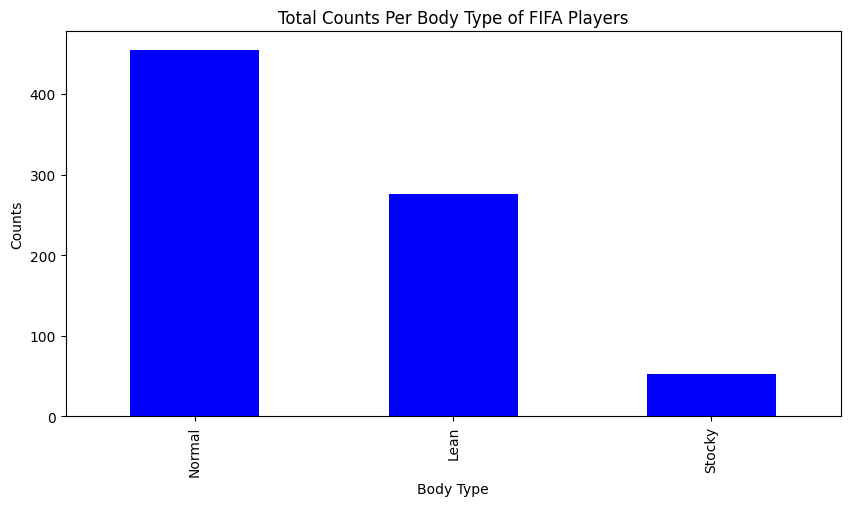

In [ ]:
# Top Counts for FIFA Players based on Body Type
total_international_rep_count = df_cleaned["body_type"].value_counts()

# Plotting bar chart
plt.figure(figsize=(10,5))
total_international_rep_count.plot(kind='bar', color="blue")
plt.xlabel("Body Type")
plt.ylabel("Counts")
plt.title("Total Counts Per Body Type of FIFA Players")
plt.gca()
plt.show()

Text(0.5, 0.98, 'Weight (Kilograms) by FIFA Player Body Type')

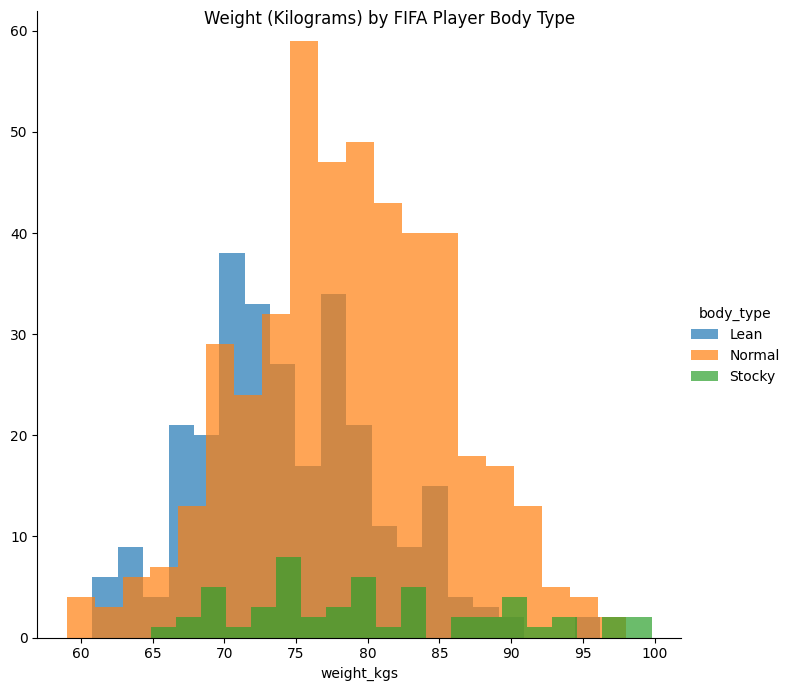

In [ ]:
# sns.FacetGrid

facetGridGraph = sns.FacetGrid(df_cleaned, hue="body_type", height=7, aspect=1)
facetGridGraph.map_dataframe(plt.hist, x="weight_kgs",bins=20, alpha=0.7)
facetGridGraph.add_legend()
facetGridGraph.fig.suptitle('Weight (Kilograms) by FIFA Player Body Type')


# Note:
# https://matplotlib.org/stable/gallery/color/set_alpha.html
# Title set as suptitle
# https://www.geeksforgeeks.org/data-visualization/seaborn-title-error-attributeerror-facetgrid-object-has-no-attribute-settitle/

# Example of what graph below is supposed to indicated:
# Close to 60 people with Normal Body Types have Weight (kg) of around 75 to 76

Text(0.5, 0.98, 'Agility Value by FIFA Player Body Type')

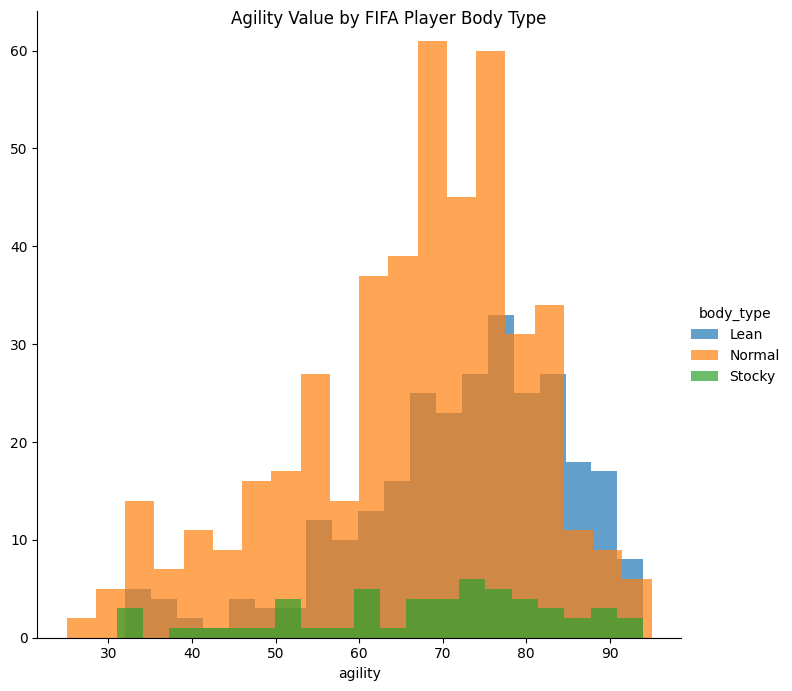

In [ ]:
# sns.FacetGrid

facetGridGraph = sns.FacetGrid(df_cleaned, hue="body_type", height=7, aspect=1)
facetGridGraph.map_dataframe(plt.hist, x="agility",bins=20, alpha=0.7)
facetGridGraph.add_legend()
facetGridGraph.fig.suptitle('Agility Value by FIFA Player Body Type')


# Note:
# https://matplotlib.org/stable/gallery/color/set_alpha.html
# Title set as suptitle
# https://www.geeksforgeeks.org/data-visualization/seaborn-title-error-attributeerror-facetgrid-object-has-no-attribute-settitle/

# Example of what graph below is supposed to be indicated:
# 60 people with Normal Body Types have an Agility Value of 70

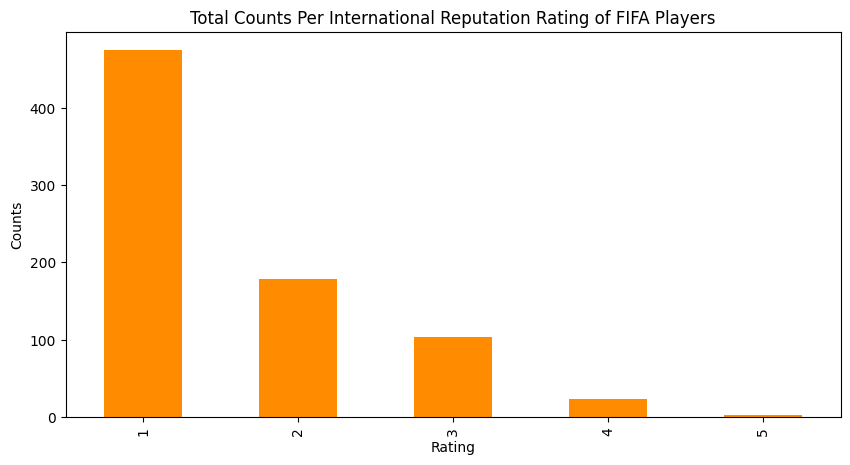

In [ ]:
# Top Ratings for FIFA Players abased on International Reputation
total_international_rep_count = df_cleaned["international_reputation(1-5)"].value_counts()

# Plotting bar chart
plt.figure(figsize=(10,5))
total_international_rep_count.plot(kind='bar', color="darkorange")
plt.xlabel("Rating")
plt.ylabel("Counts")
plt.title("Total Counts Per International Reputation Rating of FIFA Players")
plt.gca()
plt.show()


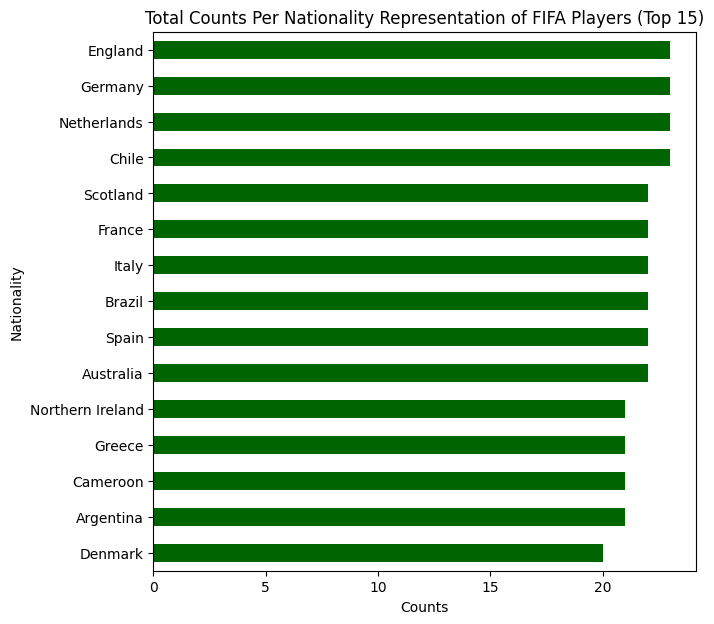

In [ ]:
# Top 15 Counts for FIFA Players based on Nationality
total_nationality_rep_count = df_cleaned["nationality"].value_counts().head(15)

# https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_values.html
total_nationality_rep_count = total_nationality_rep_count.sort_values(ascending=True)

# https://www.geeksforgeeks.org/python/draw-a-horizontal-bar-chart-with-matplotlib/

# Plotting bar chart
plt.figure(figsize=(7,7))
total_nationality_rep_count.plot(kind='barh', color="darkgreen")
plt.xlabel("Counts")
plt.ylabel("Nationality")
plt.title("Total Counts Per Nationality Representation of FIFA Players (Top 15)")
plt.gca()
plt.show()


### Methodology

1. Linear Regression Methodology and Results

    I was wondering if it would be possible, since, in my mind, I thought that if a person has a low or high weight (kgs), then there would be a trend in alignment in each FIFA players respective ability stats. For example, a person with lower weight may be able to have high agility and sprint_speed, but might have lower stamina and strength to support with that weight class; the opposite could be true for those higher weights, but I didn't know at the time if there could be a correlation until experimenting.

2. Use of Linear Regression

    After looking into the previous visualizations and results, I decided to try looking into the prediction of weight (kgs) [__target__] of each member based on the following ability stats:

    - acceleration
    - sprint_speed
    - agility
    - balance
    - jumping
    - stamina
    - strength
    - vision


In [ ]:
X = df_cleaned.copy()
X = X[["acceleration","sprint_speed","agility","balance","jumping","stamina","strength","vision",]].reset_index(drop=True)
X

,acceleration,sprint_speed,agility,balance,jumping,stamina,strength,vision
0,76,73,80,81,50,92,58,91
1,71,79,76,66,83,88,87,88
2,94,86,94,93,53,75,44,87
3,74,77,61,49,88,75,92,60
4,96,96,92,83,75,83,71,82
...,...,...,...,...,...,...,...,...
778,68,72,71,73,79,89,84,81
779,83,73,82,83,69,90,83,84
780,94,88,95,94,56,83,66,89
781,78,76,79,77,63,89,75,94


In [ ]:
y = df_cleaned['weight_kgs']
y

,weight_kgs
0,76.2
1,83.9
2,59.0
3,92.1
4,73.0
...,...
778,88.9
779,86.2
780,76.2
781,69.9


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

In [ ]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Coefficients: \n", model.coef_)

Coefficients: 
 [-0.00705948 -0.00058107 -0.02030002 -0.19294449 -0.01912356 -0.09279179
  0.31816762  0.02717042]


In [ ]:
predictions = model.predict(X_test) #y_pred

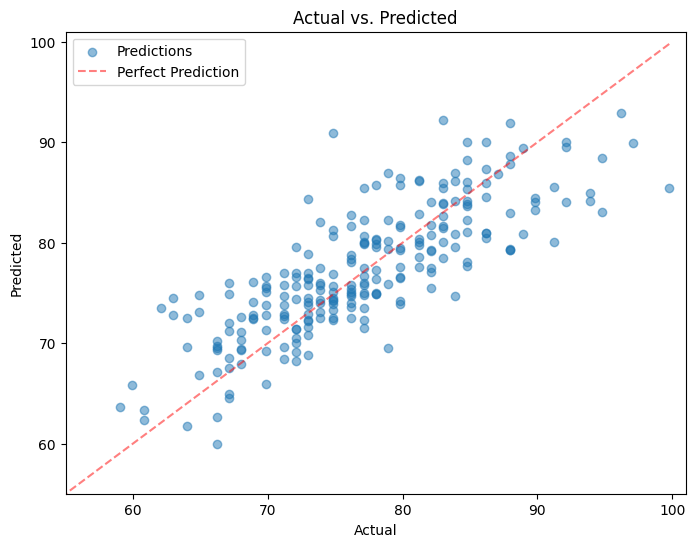

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, label='Predictions')
plt.plot([0, max(y_test)], [0, max(y_test)], '--r', alpha=0.5, label='Perfect Prediction')
plt.xlim(55,101)
plt.ylim(55,101)
plt.title('Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

RapidMiner Results to Compare

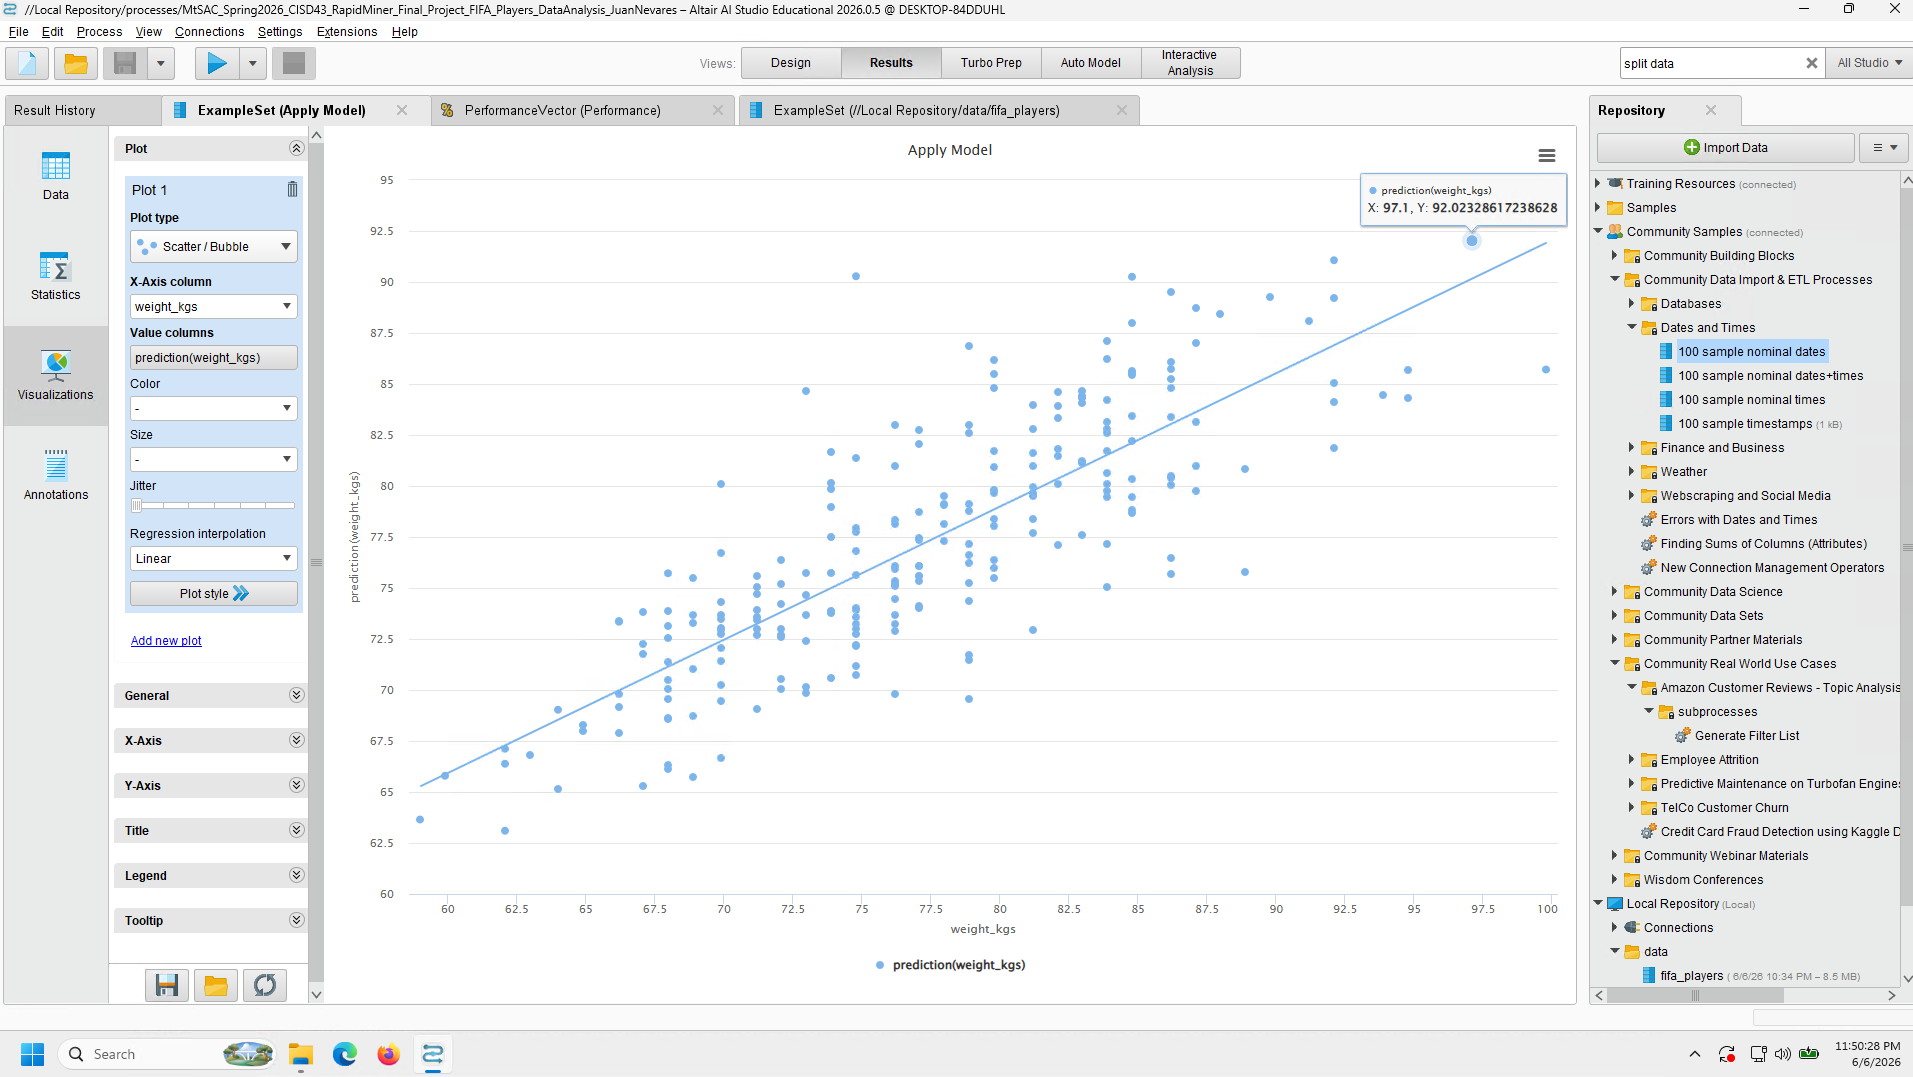


MongoDB Database Setup and Data Retrieval

In [ ]:
# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")

try:
    client.admin.command("ping")
    print("Connected to MongoDB successfully.")
except Exception as error:
    print("MongoDB connection failed.")
    print(error)

Connected to MongoDB successfully.


In [ ]:
# Create database then select it

db = client["fifa_players_db"]
print("Database select:", db.name)

Database select: fifa_players_db


In [ ]:
collection = db["player_stats"]
print("Collection select:", collection.name)

Collection select: player_stats


In [ ]:
records = df_cleaned.to_dict(orient="records")
pprint(records[0])

{'acceleration': 76,
 'age': 27,
 'agility': 80,
 'balance': 81,
 'birth_date': '2/14/1992',
 'body_type': 'Lean',
 'full_name': 'Christian  Dannemann Eriksen',
 'height_cm': 154.94,
 'international_reputation(1-5)': 3,
 'jumping': 50,
 'name': 'C. Eriksen',
 'nationality': 'Denmark',
 'overall_rating': 88,
 'penalties': 67,
 'positions': 'CAM,RM,CM',
 'sprint_speed': 73,
 'stamina': 92,
 'strength': 58,
 'vision': 91,
 'weight_kgs': 76.2}


In [ ]:
collection.delete_many({})

if records:
    result = collection.insert_many(records)
    print(f"Inserted {len(result.inserted_ids)} douments into MongoDB.")
else:
    print("No records found to insert.")

Inserted 783 douments into MongoDB.


In [ ]:
total_documents = collection.count_documents({})

print ("Total documents in the collection:", total_documents)

Total documents in the collection: 783


In [ ]:
# Retrieve the first three records
# https://www.mongodb.com/docs/manual/reference/method/db.collection.find/
# https://www.mongodb.com/docs/languages/python/pymongo-driver/current/crud/query/find/

three_records = collection.find().limit(3)
for record in three_records:
    pprint(record)

# Print the records

{'_id': ObjectId('6a2653dbd4c59ea630afa648'),
 'acceleration': 76,
 'age': 27,
 'agility': 80,
 'balance': 81,
 'birth_date': '2/14/1992',
 'body_type': 'Lean',
 'full_name': 'Christian  Dannemann Eriksen',
 'height_cm': 154.94,
 'international_reputation(1-5)': 3,
 'jumping': 50,
 'name': 'C. Eriksen',
 'nationality': 'Denmark',
 'overall_rating': 88,
 'penalties': 67,
 'positions': 'CAM,RM,CM',
 'sprint_speed': 73,
 'stamina': 92,
 'strength': 58,
 'vision': 91,
 'weight_kgs': 76.2}
{'_id': ObjectId('6a2653dbd4c59ea630afa649'),
 'acceleration': 71,
 'age': 25,
 'agility': 76,
 'balance': 66,
 'birth_date': '3/15/1993',
 'body_type': 'Normal',
 'full_name': 'Paul Pogba',
 'height_cm': 190.5,
 'international_reputation(1-5)': 4,
 'jumping': 83,
 'name': 'P. Pogba',
 'nationality': 'France',
 'overall_rating': 88,
 'penalties': 82,
 'positions': 'CM,CAM',
 'sprint_speed': 79,
 'stamina': 88,
 'strength': 87,
 'vision': 88,
 'weight_kgs': 83.9}
{'_id': ObjectId('6a2653dbd4c59ea630afa64a'

In [ ]:
query = {'body_type': "Stocky"}
result = collection.find(query)

# Convert the result to a pandas DataFrame
df_customer_query = pd.DataFrame(result)

# Display the DataFrame
df_customer_query.head(10)

,_id,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,international_reputation(1-5),body_type,acceleration,sprint_speed,agility,balance,jumping,stamina,strength,vision,penalties
0,6a2653dbd4c59ea630afa64d,S. Agüero,Sergio Leonel Agüero del Castillo,6/2/1988,30,172.72,69.9,ST,Argentina,89,4,Stocky,88,80,86,91,81,76,73,83,83
1,6a2653dbd4c59ea630afa65e,N. Süle,Niklas Süle,9/3/1995,23,195.58,97.1,CB,Germany,84,2,Stocky,52,84,33,33,38,65,94,30,32
2,6a2653dbd4c59ea630afa66c,J. Tah,Jonathan Tah,2/11/1996,23,195.58,97.1,CB,Germany,82,2,Stocky,64,77,48,44,72,63,93,61,38
3,6a2653dbd4c59ea630afa680,S. Bergwijn,Steven Bergwijn,10/8/1997,21,152.40,78.0,"LW,RW",Netherlands,80,1,Stocky,88,89,79,89,71,78,79,75,59
4,6a2653dbd4c59ea630afa681,A. Onana,André Onana,4/2/1996,22,187.96,93.0,GK,Cameroon,80,2,Stocky,64,62,68,53,80,39,67,62,27
5,6a2653dbd4c59ea630afa682,Everton Andrão,Everton Jorge Andrade Zanon,2/29/1984,35,152.40,74.8,"CDM,CM",Brazil,80,1,Stocky,69,68,78,77,67,89,71,73,61
6,6a2653dbd4c59ea630afa692,G. Medel,Gary Alexis Medel Soto,8/3/1987,31,170.18,64.9,"CDM,CB",Chile,79,3,Stocky,72,70,78,92,82,84,83,68,58
7,6a2653dbd4c59ea630afa6ab,S. Vokes,Sam Vokes,10/21/1989,29,187.96,89.8,ST,Wales,75,1,Stocky,50,55,50,60,89,73,84,70,79
8,6a2653dbd4c59ea630afa6b9,J. Svensson,Jonas Svensson,3/6/1993,26,170.18,69.9,"RB,CM",Norway,74,1,Stocky,76,79,74,86,73,89,77,65,48
9,6a2653dbd4c59ea630afa6c0,L. Cavallini,Lucas Cavallini,12/28/1992,26,182.88,88.9,ST,Canada,74,1,Stocky,76,74,62,70,68,72,84,56,70


### Conclusions


While working on this project, I was able to have a better understanding of how to apply data analysis of larger datasets, and then look into broader insights via data visualizations and machine learning via linear regression techniques on both Google Colab and Python Libraries. The use of RapidMiner also gave me better confidence in researching and experimenting with it’s GUI tools to confirm a similar results and functionality of machine learning techniques, especially when viewing the Linear Regression visualization trend showing confirmation of the relation between weight (kgs) and ability stats for the predictions. It was very satisfying to see and know and that I’m able to work through and lean towards the right path of results so long as I kept on trying to apply the correct settings to have similar results on Colab. MongoDB also worked out great in being able to accept data that was in the form of a dataframe, cleaned up after being read CSV. The data retrieval still worked as expected, so it would be great to see it being used in other projects, if need be.

Overall, this project has installed further confidence in my use of Python and other software integral towards their use within Big Data and applying further analysis. I’m quite happy with what I’ve learned, as well as the output received from working through the various steps.

###  References
- Academic (if any)
- Online (if any)

  - RapidMiner References:
  
    - https://www.youtube.com/watch?v=FWuhKEGxN48 (Remove missing values with Rapidminer by Actionable Data Science)
    - https://www.jdatalab.com/data_science_and_data_mining/2017/02/12/linear-regression-prediction.html
  
  - Other online References:
  
    - https://github.com/googlecolab/colabtools/issues/4357
    - https://github.com/googlecolab/colabtools/issues/5505
    - https://pandas.pydata.org/docs/reference/api/pandas.set_option.html-pandas.set_option
    - https://www.geeksforgeeks.org/pandas/ways-to-filter-pandas-dataframe-by-column-values/
    - https://matplotlib.org/stable/gallery/color/set_alpha.html
    - https://www.geeksforgeeks.org/data-visualization/seaborn-title-error-attributeerror-facetgrid-object-has-no-attribute-settitle/
    - https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_values.html
    - https://www.geeksforgeeks.org/python/draw-a-horizontal-bar-chart-with-matplotlib/
    - https://www.mongodb.com/docs/manual/reference/method/db.collection.find/
    - https://www.mongodb.com/docs/languages/python/pymongo-driver/current/crud/query/find/  
  

### Credits

- If you use and/or adapt your code from existing projects, you must provide links and acknowldge the authors.
> *This code is based on .... (if any)*

### Class references:
- Module 5 - KNN Lab Assignment Cancer .ipynb
  - (Completed previously)
- Module 4 - Linear Regression Lab.ipynb
  - (Completed previously)
- Module 11 NoSQL MongoDB Lab Assignment.ipynb
  - (Completed previously)
- https://github.com/lukalee/CISD-43-Big-Data-Modeling-Analysis/tree/11f9e916a3e0fed154f3a4ecec6934654b9dd6f3/FinalProject
  - (Provided by Professor for project; Attempted previously on KNN, but I moved on towards Linear Regression instead, though I would still like to give credit where this method came from)
- https://github.com/dparrad/Customer-Churn-Project
  - (Provided by Professor for project; For review project statement and correct formatting)


Credit for the following resources on installing MongoDB within Google Collab's Linux VM for this educational lab assignment:

- [MongoDB Installation on Google Colab VM by Sukree Sinthupinyo | Uploaded on Jan 27, 2025](https://www.youtube.com/watch?v=YlSZfHU7QWY)
- [Install MongoDB Community Edition on Ubuntu by the Official MongoDB Documentation](https://www.mongodb.com/docs/v8.0/tutorial/install-mongodb-on-ubuntu/)

In [ ]:
# End of Project